# 02 – Deseasonalisation

Builds the two deseasonalised residual series required by the CARMA model:

- **Temperature** `Y_t`: hourly residuals from a Fourier + trend seasonal fit.
- **Log-price** `X_t`: residuals from a Fourier + trend fit on `log(S_t + PRICE_SHIFT)`,  
  consistent with the paper model `S_t = exp(Λ_S(t) + X_t)`.  
  The constant shift `PRICE_SHIFT = 500 EUR/MWh` handles negative German day-ahead prices.

Both series are split into a **training window** (used for all downstream fitting)  
and a **test window** (reserved for out-of-sample evaluation).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from config import (
    PRICES_CSV, TEMP_CSV,
    DESEAS_DIR, FIG_DIR,
    PRICE_SHIFT,
    TRAIN_END, TEST_START,
    K_HOUR_TEMP, K_YEAR_TEMP,
    K_HOUR_PRICE, K_YEAR_PRICE,
    TEMP_RESID_CSV, PRICE_LOGRESID_CSV,
    TEMP_RESID_TRAIN_CSV, TEMP_RESID_TEST_CSV,
    PRICE_RESID_TRAIN_CSV, PRICE_RESID_TEST_CSV,
)

print('PRICE_SHIFT =', PRICE_SHIFT, 'EUR/MWh')
print('Train end  :', TRAIN_END)
print('Test start :', TEST_START)

PRICE_SHIFT = 500.0 EUR/MWh
Train end  : 2024-12-31
Test start : 2025-01-01


## 1.  Load raw data

In [2]:
# ── Temperature ──────────────────────────────────────────────────────────────
temp_raw = pd.read_csv(TEMP_CSV, index_col=0, parse_dates=True)
temp_raw.index = pd.to_datetime(temp_raw.index, utc=True)
temp_raw = temp_raw.sort_index().asfreq('h').interpolate('linear')
temp = temp_raw['temperature_c'].copy()
print('Temperature:', temp.index[0], '→', temp.index[-1], f'  n={len(temp):,}')

# ── Prices ───────────────────────────────────────────────────────────────────
price_raw = pd.read_csv(PRICES_CSV, index_col=0, parse_dates=True)
price_raw.index = pd.to_datetime(price_raw.index, utc=True)
price_raw = price_raw.sort_index().asfreq('h').interpolate('linear')
price = price_raw['price_eur_mwh'].copy()
print('Price:      ', price.index[0], '→', price.index[-1], f'  n={len(price):,}')
print(f'Price range: [{price.min():.1f}, {price.max():.1f}] EUR/MWh')
print(f'Negative prices: {(price < 0).sum():,} out of {len(price):,} ({100*(price<0).mean():.1f}%)')

# ── Log-price (CE-1 fix: work in log-space) ──────────────────────────────────
log_price = np.log(price + PRICE_SHIFT)
# Fix any -inf from price == -PRICE_SHIFT edge case (interpolate)
if np.isinf(log_price).any():
    print(f'WARN: {np.isinf(log_price).sum()} -inf value(s) in log_price — interpolating')
    log_price[np.isinf(log_price)] = np.nan
    log_price = log_price.interpolate('linear')
print(f'\nlog(price + {PRICE_SHIFT}) range: [{log_price.min():.3f}, {log_price.max():.3f}]')
assert log_price.isna().sum() == 0, 'NaN in log_price – increase PRICE_SHIFT'

Temperature: 2020-01-01 00:00:00+00:00 → 2025-12-30 23:00:00+00:00   n=52,584


Price:       2023-01-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00   n=26,281
Price range: [-500.0, 936.3] EUR/MWh
Negative prices: 1,333 out of 26,281 (5.1%)
WARN: 1 -inf value(s) in log_price — interpolating

log(price + 500.0) range: [4.615, 7.270]


/home/sven/bin/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 2.  Seasonal regression helpers

In [3]:
def fourier_block(x, period, K):
    'Build 2K Fourier columns (cos/sin pairs) for given period.'
    omega = 2 * np.pi / period
    cols = []
    for k in range(1, K + 1):
        cols.append(np.cos(k * omega * x))
        cols.append(np.sin(k * omega * x))
    return np.column_stack(cols)


def fit_seasonal(series, K_hour, K_year, include_dow=False):
    '''
    Fit a Fourier seasonal regression to an hourly Series.

    Regressors
    ----------
    - intercept + linear trend
    - K_hour harmonics for 24-h intraday cycle
    - K_year harmonics for 8760-h annual cycle
    - K_hour x K_year interaction terms
    - (optionally) 6 day-of-week dummies

    Returns
    -------
    fit   : fitted seasonal Series (same index as series)
    resid : deseasonalised residual Series
    beta  : OLS coefficient array
    '''
    x = ((series.index - series.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
    y = series.to_numpy(dtype=float)

    P_day  = 24.0
    P_year = 365.25 * 24.0

    block_h = fourier_block(x, P_day,  K_hour)
    block_y = fourier_block(x, P_year, K_year)

    # interaction columns
    inter_cols = [block_h[:, i] * block_y[:, j]
                  for i in range(block_h.shape[1])
                  for j in range(block_y.shape[1])]
    block_inter = np.column_stack(inter_cols)

    cols = [np.ones(len(x)), x, block_h, block_y, block_inter]

    if include_dow:
        dow = series.index.dayofweek  # 0=Mon … 6=Sun
        for d in range(1, 7):         # Sunday is baseline
            cols.append((dow == d).astype(float))

    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_fit   = X @ beta
    y_resid = y - y_fit

    fit_s   = pd.Series(y_fit,   index=series.index, name='seasonal_fit')
    resid_s = pd.Series(y_resid, index=series.index, name='deseasoned')
    return fit_s, resid_s, beta, X

## 3.  Temperature deseasonalisation

Fit seasonal model on **training window only**, then evaluate on full series.

In [4]:
# Fit on training window
temp_train = temp[temp.index <= pd.Timestamp(TRAIN_END, tz='UTC')]
temp_test  = temp[temp.index >  pd.Timestamp(TRAIN_END, tz='UTC')]

_, _, beta_temp, _ = fit_seasonal(temp_train, K_HOUR_TEMP, K_YEAR_TEMP)

# Evaluate on full series using the TRAINING-estimated coefficients
_, temp_resid_full, _, X_temp_full = fit_seasonal(temp, K_HOUR_TEMP, K_YEAR_TEMP)
# Re-apply training beta to full X
x_all = ((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
P_day_t = 24.0; P_year_t = 365.25 * 24.0
bh = fourier_block(x_all, P_day_t, K_HOUR_TEMP)
by = fourier_block(x_all, P_year_t, K_YEAR_TEMP)
bi_cols = [bh[:, i] * by[:, j] for i in range(bh.shape[1]) for j in range(by.shape[1])]
X_full_temp = np.column_stack([np.ones(len(x_all)), x_all, bh, by, np.column_stack(bi_cols)])

temp_fit_full = pd.Series(X_full_temp[:, :len(beta_temp)] @ beta_temp[:X_full_temp.shape[1]],
                          index=temp.index)
temp_resid_full = temp - temp_fit_full
temp_resid_full.name = 'temp_deseasoned'

print('Temperature residuals — summary')
print(pd.Series({'mean': temp_resid_full.mean(), 'std': temp_resid_full.std(),
                 'skew': stats.skew(temp_resid_full), 'kurt': stats.kurtosis(temp_resid_full, fisher=True)}).round(4))

Temperature residuals — summary
mean   -0.1720
std     3.7385
skew    0.0454
kurt    0.4315
dtype: float64


In [5]:
# ADF stationarity test
adf_temp = adfuller(temp_resid_full.dropna(), maxlag=48)
print(f'ADF statistic: {adf_temp[0]:.4f}   p-value: {adf_temp[1]:.4f}')
if adf_temp[1] < 0.05:
    print('PASS: temperature residuals are stationary at 5% level.')
else:
    print('WARN: temperature residuals may be non-stationary – inspect trend.')

ADF statistic: -18.3111   p-value: 0.0000
PASS: temperature residuals are stationary at 5% level.


## 4.  Log-price deseasonalisation

Model: `log(S_t + 500) = Λ_S(t) + X_t`  
Seasonal fit on training window (2023-01-01 to 2024-12-31). Day-of-week dummies included.

In [6]:
# Training window for prices
lp_train = log_price[log_price.index <= pd.Timestamp(TRAIN_END, tz='UTC')]
lp_test  = log_price[log_price.index >  pd.Timestamp(TRAIN_END, tz='UTC')]

# Fit seasonal model on training data with day-of-week dummies
x_tr = ((lp_train.index - lp_train.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
y_lp = lp_train.to_numpy(dtype=float)

P_day_p  = 24.0
P_year_p = 365.25 * 24.0

bh_tr = fourier_block(x_tr, P_day_p,  K_HOUR_PRICE)
by_tr = fourier_block(x_tr, P_year_p, K_YEAR_PRICE)
bi_tr_cols = [bh_tr[:, i] * by_tr[:, j]
              for i in range(bh_tr.shape[1]) for j in range(by_tr.shape[1])]

# day-of-week dummies (Mon-Sat; Sun is baseline)
dow_tr = lp_train.index.dayofweek
dow_dummies_tr = np.column_stack([(dow_tr == d).astype(float) for d in range(1, 7)])

X_lp_tr = np.column_stack([
    np.ones(len(x_tr)), x_tr,
    bh_tr, by_tr, np.column_stack(bi_tr_cols),
    dow_dummies_tr
])

beta_lp, *_ = np.linalg.lstsq(X_lp_tr, y_lp, rcond=None)

print(f'Log-price seasonal model: {X_lp_tr.shape[1]} regressors, {len(y_lp):,} training obs')
resid_tr = y_lp - X_lp_tr @ beta_lp
print(f'In-sample RMSE: {np.sqrt(np.mean(resid_tr**2)):.4f}  (log-EUR/MWh)')

Log-price seasonal model: 56 regressors, 17,521 training obs
In-sample RMSE: 0.0673  (log-EUR/MWh)


In [7]:
# Apply training beta to full price series
x_all_lp = ((log_price.index - lp_train.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
bh_all   = fourier_block(x_all_lp, P_day_p,  K_HOUR_PRICE)
by_all   = fourier_block(x_all_lp, P_year_p, K_YEAR_PRICE)
bi_all   = np.column_stack([bh_all[:, i] * by_all[:, j]
                            for i in range(bh_all.shape[1])
                            for j in range(by_all.shape[1])])

dow_all  = log_price.index.dayofweek
dow_dum_all = np.column_stack([(dow_all == d).astype(float) for d in range(1, 7)])

X_lp_all = np.column_stack([
    np.ones(len(x_all_lp)), x_all_lp,
    bh_all, by_all, bi_all,
    dow_dum_all
])

lp_fit_all = X_lp_all @ beta_lp
lp_resid_all = log_price.values - lp_fit_all
lp_resid_series = pd.Series(lp_resid_all, index=log_price.index, name='logprice_deseasoned')

print('Log-price residuals — summary')
print(pd.Series({'mean': lp_resid_series.mean(), 'std': lp_resid_series.std(),
                 'skew': stats.skew(lp_resid_series),
                 'kurt': stats.kurtosis(lp_resid_series, fisher=True)}).round(4))
print(f'\nmin={lp_resid_series.min():.3f}  max={lp_resid_series.max():.3f}')

Log-price residuals — summary
mean     0.0161
std      0.0711
skew    -0.3801
kurt    20.4512
dtype: float64

min=-1.628  max=0.835


In [8]:
# ADF test
adf_lp = adfuller(lp_resid_series.dropna(), maxlag=48)
print(f'ADF statistic: {adf_lp[0]:.4f}   p-value: {adf_lp[1]:.4f}')
if adf_lp[1] < 0.05:
    print('PASS: log-price residuals are stationary at 5% level.')
else:
    print('WARN: log-price residuals may be non-stationary – consider adding piecewise trend.')

ADF statistic: -12.4031   p-value: 0.0000
PASS: log-price residuals are stationary at 5% level.


## 5.  Diagnostic plots

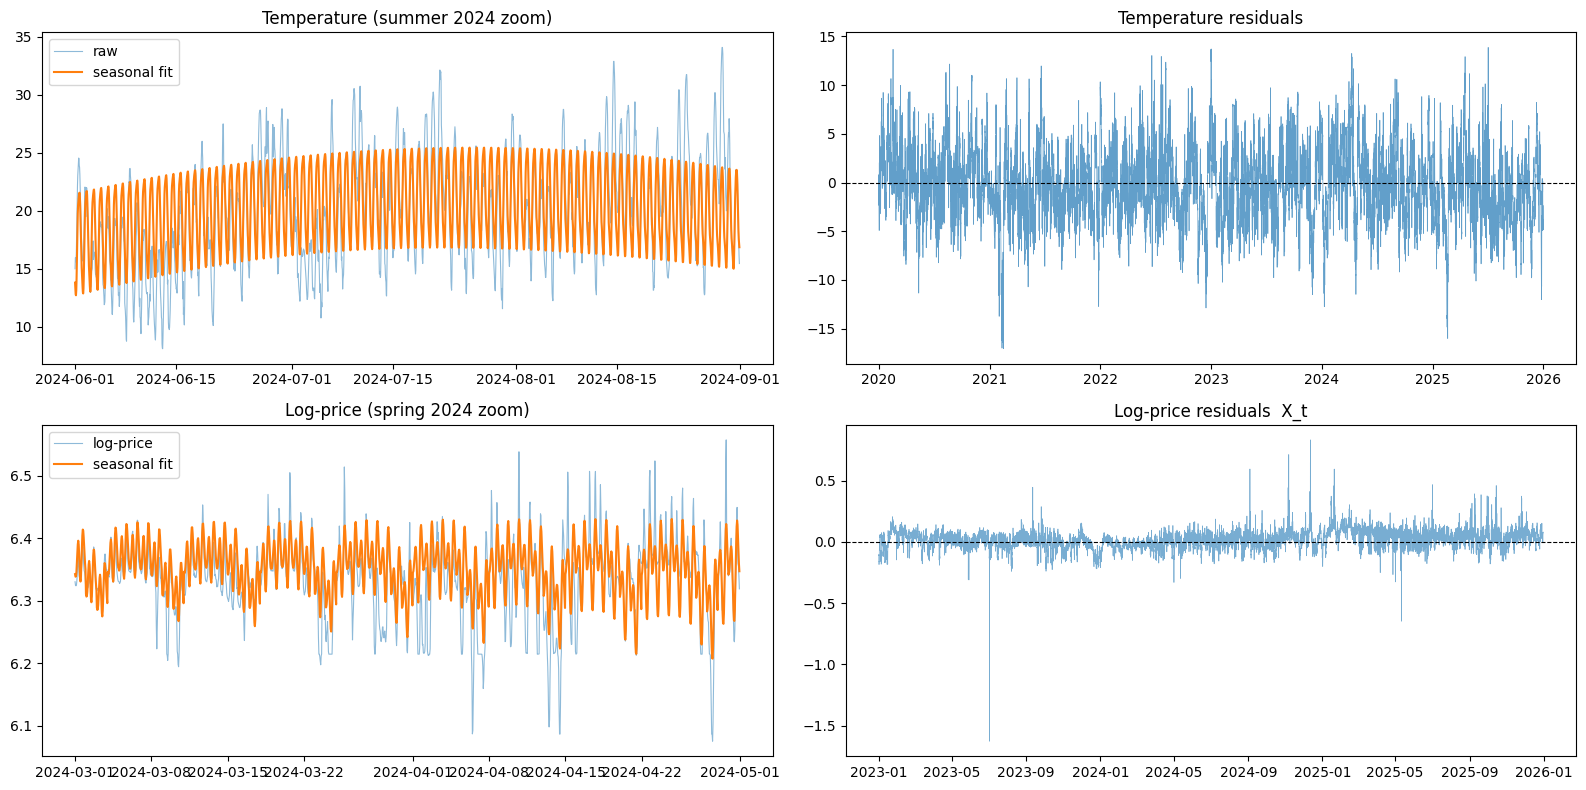

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Temperature: raw vs fitted
zoom = slice('2024-06-01', '2024-08-31')
ax = axes[0, 0]
ax.plot(temp[zoom].index, temp[zoom].values, alpha=0.5, label='raw', lw=0.8)
ax.plot(temp[zoom].index, temp_fit_full[zoom].values, label='seasonal fit', lw=1.5)
ax.set_title('Temperature (summer 2024 zoom)')
ax.legend()

# Temperature residuals
ax = axes[0, 1]
ax.plot(temp_resid_full.index, temp_resid_full.values, lw=0.5, alpha=0.7)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('Temperature residuals')

# Log-price: raw vs fitted
zoom_p = slice('2024-03-01', '2024-04-30')
ax = axes[1, 0]
ax.plot(log_price[zoom_p].index, log_price[zoom_p].values, alpha=0.5, label='log-price', lw=0.8)
ax.plot(log_price[zoom_p].index, pd.Series(lp_fit_all, index=log_price.index)[zoom_p].values,
        label='seasonal fit', lw=1.5)
ax.set_title('Log-price (spring 2024 zoom)')
ax.legend()

# Log-price residuals
ax = axes[1, 1]
ax.plot(lp_resid_series.index, lp_resid_series.values, lw=0.5, alpha=0.6)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('Log-price residuals  X_t')

plt.tight_layout()
plt.savefig(FIG_DIR / 'deseasoned_series.png', dpi=150)
plt.show()

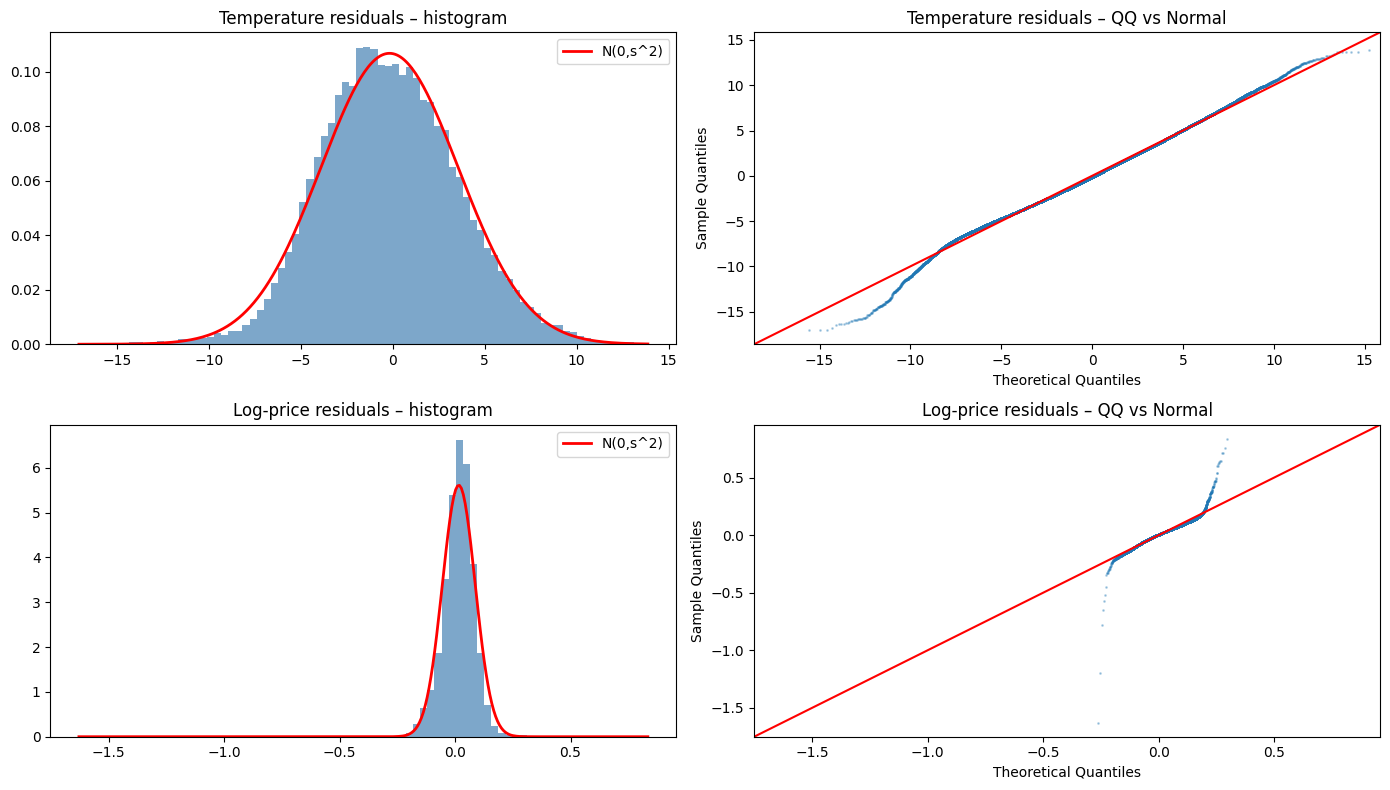

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

from statsmodels.graphics.gofplots import qqplot

# Temperature
for row, (ser, label) in enumerate([(temp_resid_full, 'Temperature residuals'),
                                     (lp_resid_series, 'Log-price residuals')]):
    axes[row, 0].hist(ser.dropna(), bins=80, density=True, color='steelblue', alpha=0.7)
    xg = np.linspace(ser.min(), ser.max(), 300)
    axes[row, 0].plot(xg, stats.norm.pdf(xg, ser.mean(), ser.std()), 'r-', lw=2, label='N(0,s^2)')
    axes[row, 0].set_title(f'{label} – histogram')
    axes[row, 0].legend()

    qqplot(ser.dropna(), dist=stats.norm, loc=ser.mean(), scale=ser.std(),
           line='45', ax=axes[row, 1], markersize=1, alpha=0.3)
    axes[row, 1].set_title(f'{label} – QQ vs Normal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'residual_diagnostics.png', dpi=150)
plt.show()

## 6.  Save outputs

In [11]:
# ── Train / test split ─────────────────────────────────────────────────────
tr_mask_t  = temp_resid_full.index <= pd.Timestamp(TRAIN_END, tz='UTC')
tst_mask_t = temp_resid_full.index >  pd.Timestamp(TRAIN_END, tz='UTC')
tr_mask_p  = lp_resid_series.index <= pd.Timestamp(TRAIN_END, tz='UTC')
tst_mask_p = lp_resid_series.index >  pd.Timestamp(TRAIN_END, tz='UTC')

# Full residuals
temp_resid_full.to_frame().to_csv(TEMP_RESID_CSV)
lp_resid_series.to_frame().to_csv(PRICE_LOGRESID_CSV)

# Training subsets
temp_resid_full[tr_mask_t].to_frame().to_csv(TEMP_RESID_TRAIN_CSV)
lp_resid_series[tr_mask_p].to_frame().to_csv(PRICE_RESID_TRAIN_CSV)

# Test subsets
temp_resid_full[tst_mask_t].to_frame().to_csv(TEMP_RESID_TEST_CSV)
lp_resid_series[tst_mask_p].to_frame().to_csv(PRICE_RESID_TEST_CSV)

print('Saved:')
for p in [TEMP_RESID_CSV, PRICE_LOGRESID_CSV,
          TEMP_RESID_TRAIN_CSV, PRICE_RESID_TRAIN_CSV,
          TEMP_RESID_TEST_CSV, PRICE_RESID_TEST_CSV]:
    print(f'  {p}')

print(f'\nTraining obs  – temp: {tr_mask_t.sum():,}   price: {tr_mask_p.sum():,}')
print(f'Test obs      – temp: {tst_mask_t.sum():,}   price: {tst_mask_p.sum():,}')

Saved:
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/data/deseasonalised/temp_resid.csv
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/data/deseasonalised/price_logresid.csv
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/data/deseasonalised/temp_resid_train.csv
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/data/deseasonalised/price_logresid_train.csv
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-QUANTO/Pricing_and_Hedging_of_Quanto_Options_in_Renewable_Energy_Markets_using_CARMA/Code/data/deseasonalised/temp_resid_test.csv
  /home/sven/Nextcloud/Research/Projects/Open/GK25:CARMA-Q